# Linux Networking Fundamentals - Enhanced Edition

This notebook does **not** replace `Lesson4-Linux_Networking_Fundamentals.ipynb` - read that one first. This is a companion that goes deeper, with diagrams and a couple of small interactive tools.

What's new here:
- A diagram of the TCP/IP layering model and how encapsulation works.
- A worked CIDR/subnetting calculator you can run against your own addresses.
- A deeper look at routing table fields, as a table.
- A diagram of the DNS resolution order.
- A full comparison table of `iproute2` vs legacy `net-tools` commands.
- A diagram of the TCP three-way handshake and connection teardown.
- A common-ports reference table plus a port classifier tool.
- A diagram of `iptables`/`nftables` packet traversal through the built-in chains.
- A troubleshooting checklist.
- Review questions, this time with answers.


## 1. The TCP/IP Layering Model

Every network conversation is built out of layers, each one wrapping ("encapsulating") the layer above it in its own header as data moves down the stack to be sent, and each layer stripping its own header back off as data moves up the stack on the receiving end.

| Layer | Example protocols | Unit of data | Addressing |
|---|---|---|---|
| Application | HTTP, DNS, SSH | Message | - |
| Transport | TCP, UDP | Segment (TCP) / Datagram (UDP) | Port |
| Internet | IP, ICMP | Packet | IP address |
| Link | Ethernet, Wi-Fi | Frame | MAC address |

A useful way to remember it: the application layer doesn't know about IP addresses, and the link layer doesn't know about ports - each layer only understands its own header.


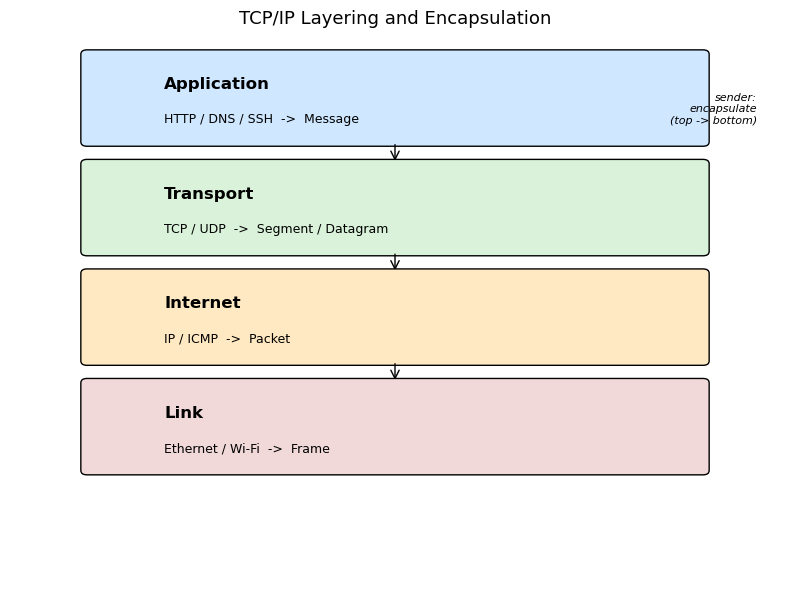

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

layers = [
    ("Application", "HTTP / DNS / SSH  ->  Message", "#cfe8ff"),
    ("Transport", "TCP / UDP  ->  Segment / Datagram", "#d9f2d9"),
    ("Internet", "IP / ICMP  ->  Packet", "#ffe9c2"),
    ("Link", "Ethernet / Wi-Fi  ->  Frame", "#f2d9d9"),
]

y = 8.0
box_h = 1.6
for name, detail, color in layers:
    box = FancyBboxPatch((1, y), 8, box_h, boxstyle="round,pad=0.08",
                          edgecolor="black", facecolor=color)
    ax.add_patch(box)
    ax.text(2, y + box_h * 0.65, name, ha="left", va="center", fontsize=12, fontweight="bold")
    ax.text(2, y + box_h * 0.25, detail, ha="left", va="center", fontsize=9)
    if y > 2.5:
        arrow = FancyArrowPatch((5, y), (5, y - 0.4), arrowstyle="->", mutation_scale=15)
        ax.add_patch(arrow)
    y -= 2.0

ax.text(9.7, 8.9, "sender:\nencapsulate\n(top -> bottom)", ha="right", va="top", fontsize=8, style="italic")
ax.set_title("TCP/IP Layering and Encapsulation", fontsize=13)
plt.tight_layout()
plt.show()


## 2. IPv4 Addressing Arithmetic

A `/N` prefix length says how many of the 32 bits belong to the network. The remaining `32 - N` bits are the host portion.

| Prefix | Subnet mask | Host bits | Usable hosts | Typical use |
|---|---|---|---|---|
| /8 | 255.0.0.0 | 24 | 16,777,214 | Very large network (class A) |
| /16 | 255.255.0.0 | 16 | 65,534 | Large LAN (class B) |
| /24 | 255.255.255.0 | 8 | 254 | Typical office/home LAN (class C) |
| /28 | 255.255.255.240 | 4 | 14 | Small subnet (e.g. a rack of servers) |
| /30 | 255.255.255.252 | 2 | 2 | Point-to-point link (e.g. router to router) |

"Usable hosts" is `2^(host bits) - 2`, subtracting the network address (all host bits 0) and the broadcast address (all host bits 1) - except for `/31` and `/32`, which are special cases used for point-to-point links and single-host routes respectively.


In [2]:
import ipaddress


def explain_cidr(cidr):
    """Break a CIDR string like '192.168.1.10/24' down into its components."""
    iface = ipaddress.ip_interface(cidr)
    network = iface.network
    total_hosts = network.num_addresses
    usable = list(network.hosts())

    print(f"        input: {cidr}")
    print(f"    IP address: {iface.ip}")
    print(f"   subnet mask: {network.netmask}")
    print(f"prefix length: /{network.prefixlen}")
    print(f"network address: {network.network_address}")
    print(f"broadcast address: {network.broadcast_address}")
    print(f"     total addresses: {total_hosts}")
    print(f"      usable hosts: {len(usable) if network.prefixlen < 31 else total_hosts}")
    if usable:
        print(f"  first/last usable: {usable[0]} - {usable[-1]}")


explain_cidr("192.168.1.10/24")
print()
explain_cidr("10.0.4.130/28")


        input: 192.168.1.10/24
    IP address: 192.168.1.10
   subnet mask: 255.255.255.0
prefix length: /24
network address: 192.168.1.0
broadcast address: 192.168.1.255
     total addresses: 256
      usable hosts: 254
  first/last usable: 192.168.1.1 - 192.168.1.254

        input: 10.0.4.130/28
    IP address: 10.0.4.130
   subnet mask: 255.255.255.240
prefix length: /28
network address: 10.0.4.128
broadcast address: 10.0.4.143
     total addresses: 16
      usable hosts: 14
  first/last usable: 10.0.4.129 - 10.0.4.142


## 3. Routing Table Fields, in More Depth

`ip route show` output packs several fields onto one line. For example:

```
default via 192.168.1.1 dev eth0 proto dhcp metric 100
192.168.1.0/24 dev eth0 proto kernel scope link src 192.168.1.10
```

| Field | Meaning |
|---|---|
| `default` / `<network>/<prefix>` | The destination this route matches. `default` is shorthand for `0.0.0.0/0`. |
| `via <ip>` | The next-hop gateway to forward through. Omitted for directly-connected networks. |
| `dev <if>` | The local interface the packet is sent out of. |
| `proto <source>` | Where the route came from: `kernel` (auto-created for a connected network), `dhcp` (learned from DHCP), `static` (manually added), `boot`. |
| `scope <scope>` | `link` means the destination is on the local network segment (no gateway needed); `global` means it can be anywhere. |
| `src <ip>` | The source address the kernel will use when sending packets that match this route. |
| `metric <n>` | Priority when multiple routes could match the same destination - lower wins. |

When two routes could both match a destination, the kernel prefers the **more specific prefix** first (e.g. `/24` beats `default`), and only falls back to `metric` to break ties between routes of the same prefix length.


## 4. DNS Resolution Order, in More Depth

`getent hosts <name>` (and anything else that resolves a name through the C library, which is almost everything) follows the order configured in `/etc/nsswitch.conf`'s `hosts:` line - typically `files dns`, meaning `/etc/hosts` is authoritative and checked first, and DNS is only consulted if there's no match there.


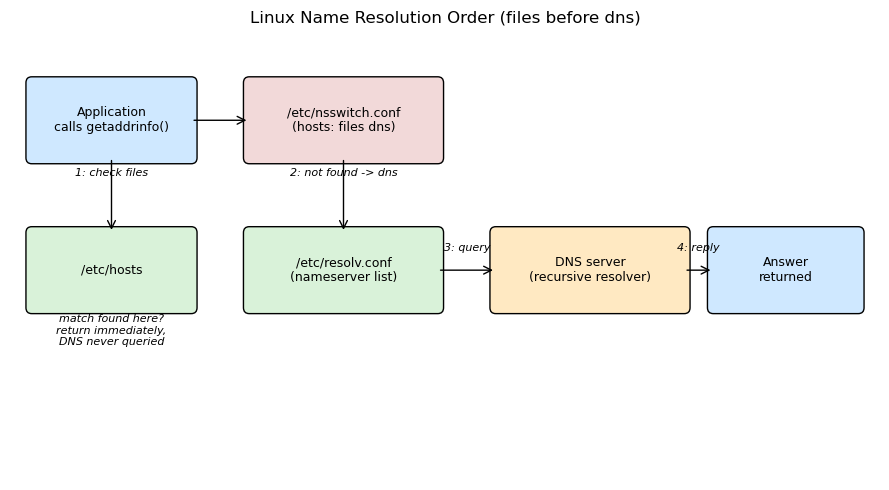

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")


def box(x, y, w, h, label, color="#e8e8e8"):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                        edgecolor="black", facecolor=color)
    ax.add_patch(b)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=9)


def arrow(x1, y1, x2, y2, label=""):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=14)
    ax.add_patch(a)
    if label:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.25, label, ha="center", fontsize=8, style="italic")


box(0.3, 4.3, 2.2, 1, "Application\ncalls getaddrinfo()", "#cfe8ff")
box(3.3, 4.3, 2.6, 1, "/etc/nsswitch.conf\n(hosts: files dns)", "#f2d9d9")
box(0.3, 2.3, 2.2, 1, "/etc/hosts", "#d9f2d9")
box(3.3, 2.3, 2.6, 1, "/etc/resolv.conf\n(nameserver list)", "#d9f2d9")
box(6.7, 2.3, 2.6, 1, "DNS server\n(recursive resolver)", "#ffe9c2")
box(9.7, 2.3, 2, 1, "Answer\nreturned", "#cfe8ff")

arrow(1.4, 4.3, 1.4, 3.3, "1: check files")
arrow(2.5, 4.8, 3.3, 4.8, "")
arrow(4.6, 4.3, 4.6, 3.3, "2: not found -> dns")
arrow(5.9, 2.8, 6.7, 2.8, "3: query")
arrow(9.3, 2.8, 9.7, 2.8, "4: reply")
ax.text(1.4, 1.8, "match found here?\nreturn immediately,\nDNS never queried", ha="center", fontsize=8, style="italic")

ax.set_title("Linux Name Resolution Order (files before dns)", fontsize=12)
plt.tight_layout()
plt.show()


## 5. `ip`/`ss` vs Legacy Tools: Full Comparison

| Task | Legacy (`net-tools`) | Modern (`iproute2`) |
|---|---|---|
| Show addresses | `ifconfig` | `ip addr` (`ip a`) |
| Show interface state | `ifconfig` | `ip link` (`ip l`) |
| Bring interface up/down | `ifconfig eth0 up/down` | `ip link set eth0 up/down` |
| Show routing table | `route -n` | `ip route` (`ip r`) |
| Add a route | `route add ...` | `ip route add ...` |
| Show listening sockets | `netstat -tulpn` | `ss -tulpn` |
| Show ARP/neighbor table | `arp -a` | `ip neigh` |
| Show interface statistics | `ifconfig` (counters) | `ip -s link` |

`net-tools` (`ifconfig`, `netstat`, `route`, `arp`) has been unmaintained for years and is not installed by default on many current distributions. `iproute2` (`ip`, `ss`) is actively maintained, understands modern kernel features (network namespaces, VRFs, policy routing), and is the toolkit worth building muscle memory around - but `net-tools` output still shows up constantly in older tutorials, exam objectives, and scripts, so recognizing it is still useful.


## 6. The TCP Three-Way Handshake and Connection States

TCP is connection-oriented: before any data flows, the client and server synchronize sequence numbers with a three-step exchange.

1. **SYN** - client sends a segment with the `SYN` flag set and an initial sequence number.
2. **SYN-ACK** - server replies with its own `SYN`, plus an `ACK` acknowledging the client's sequence number.
3. **ACK** - client acknowledges the server's sequence number. The connection is now `ESTABLISHED`.

Teardown normally uses a four-step `FIN`/`ACK` exchange in each direction (each side closes independently), which is why you'll see a connection linger briefly in `TIME_WAIT` after it closes - that's the side that sent the last `ACK` waiting in case it needs to be retransmitted.


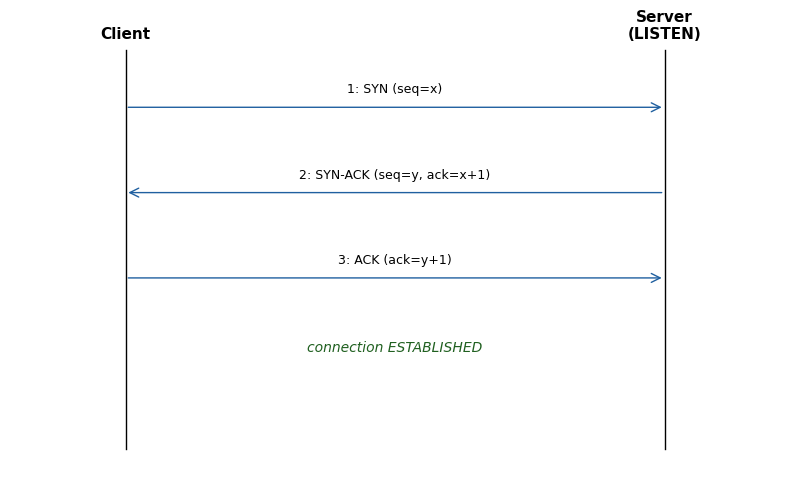

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

client_x, server_x = 1.5, 8.5
ax.plot([client_x, client_x], [0.5, 7.5], color="black", linewidth=1)
ax.plot([server_x, server_x], [0.5, 7.5], color="black", linewidth=1)
ax.text(client_x, 7.7, "Client", ha="center", fontsize=11, fontweight="bold")
ax.text(server_x, 7.7, "Server\n(LISTEN)", ha="center", fontsize=11, fontweight="bold")

steps = [
    (6.5, client_x, server_x, "1: SYN (seq=x)"),
    (5.0, server_x, client_x, "2: SYN-ACK (seq=y, ack=x+1)"),
    (3.5, client_x, server_x, "3: ACK (ack=y+1)"),
]
for y, x1, x2, label in steps:
    arrow = FancyArrowPatch((x1, y), (x2, y), arrowstyle="->", mutation_scale=16, color="#2060a0")
    ax.add_patch(arrow)
    ax.text((x1 + x2) / 2, y + 0.25, label, ha="center", fontsize=9)

ax.text((client_x + server_x) / 2, 2.2, "connection ESTABLISHED", ha="center", fontsize=10,
        style="italic", color="#206020")

plt.tight_layout()
plt.show()


## 7. Common Ports Reference

| Range | Name | Notes |
|---|---|---|
| 0-1023 | Well-known ports | Require root to bind on Linux; reserved for standard services. |
| 1024-49151 | Registered ports | Assigned to specific applications by IANA but bindable by any user. |
| 49152-65535 | Dynamic/ephemeral ports | Used automatically as the *source* port for outgoing connections. |

| Port | Protocol | Service |
|---|---|---|
| 20/21 | TCP | FTP data/control |
| 22 | TCP | SSH |
| 23 | TCP | Telnet |
| 25 | TCP | SMTP |
| 53 | TCP/UDP | DNS |
| 67/68 | UDP | DHCP server/client |
| 80 | TCP | HTTP |
| 110 | TCP | POP3 |
| 123 | UDP | NTP |
| 143 | TCP | IMAP |
| 443 | TCP | HTTPS |
| 3306 | TCP | MySQL |
| 5432 | TCP | PostgreSQL |


In [5]:
KNOWN_PORTS = {
    20: "FTP (data)", 21: "FTP (control)", 22: "SSH", 23: "Telnet",
    25: "SMTP", 53: "DNS", 67: "DHCP (server)", 68: "DHCP (client)",
    80: "HTTP", 110: "POP3", 123: "NTP", 143: "IMAP", 443: "HTTPS",
    3306: "MySQL", 5432: "PostgreSQL",
}


def classify_port(port):
    """Classify a port number by range and, if recognized, name the service."""
    if not (0 <= port <= 65535):
        raise ValueError("port must be between 0 and 65535")

    if port <= 1023:
        range_name = "well-known (0-1023, requires root to bind)"
    elif port <= 49151:
        range_name = "registered (1024-49151)"
    else:
        range_name = "dynamic/ephemeral (49152-65535)"

    service = KNOWN_PORTS.get(port, "not a commonly recognized service")
    print(f"  port: {port}")
    print(f" range: {range_name}")
    print(f"service: {service}")


classify_port(22)
print()
classify_port(51820)
print()
classify_port(8080)


  port: 22
 range: well-known (0-1023, requires root to bind)
service: SSH

  port: 51820
 range: dynamic/ephemeral (49152-65535)
service: not a commonly recognized service

  port: 8080
 range: registered (1024-49151)
service: not a commonly recognized service


## 8. `iptables`/`nftables`: Packet Traversal

Not every chain sees every packet - which chains a packet passes through depends on whether it's destined for the local host, originates from the local host, or is only being routed through it.

- A packet **arriving for this host** passes through `PREROUTING` -> routing decision -> `INPUT`.
- A packet **originating from this host** passes through `OUTPUT` -> routing decision -> `POSTROUTING`.
- A packet **only being forwarded** (this host acting as a router) passes through `PREROUTING` -> routing decision -> `FORWARD` -> `POSTROUTING`. It never touches `INPUT` or `OUTPUT`.


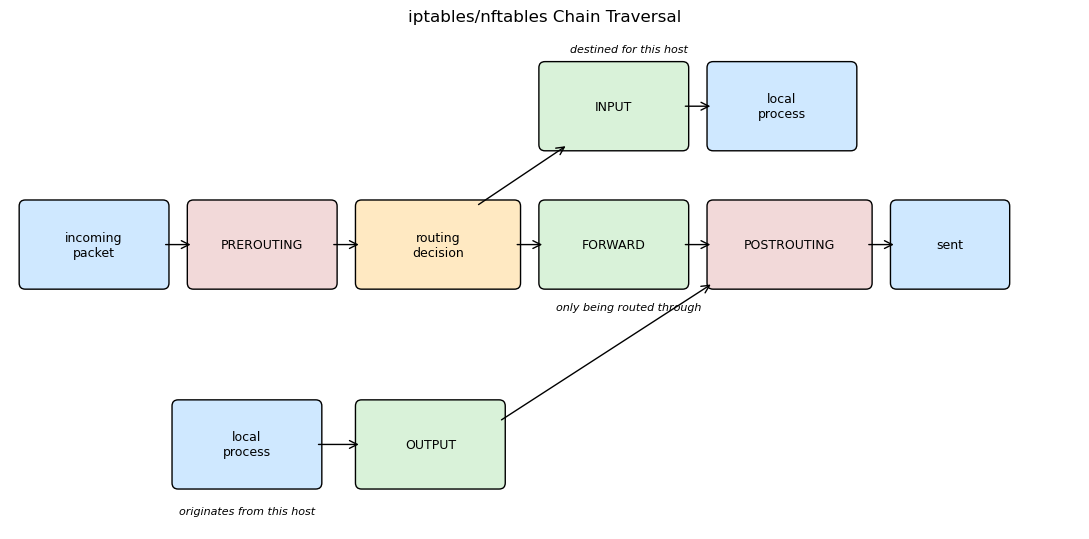

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 6.5)
ax.axis("off")


def box(x, y, w, h, label, color="#e8e8e8"):
    b = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.08",
                        edgecolor="black", facecolor=color)
    ax.add_patch(b)
    ax.text(x + w / 2, y + h / 2, label, ha="center", va="center", fontsize=9)


def arrow(x1, y1, x2, y2):
    a = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle="->", mutation_scale=14)
    ax.add_patch(a)


# main lane: incoming packet -> PREROUTING -> routing decision -> FORWARD -> POSTROUTING -> sent
box(0.2, 3.2, 1.8, 1, "incoming\npacket", "#cfe8ff")
box(2.4, 3.2, 1.8, 1, "PREROUTING", "#f2d9d9")
box(4.6, 3.2, 2, 1, "routing\ndecision", "#ffe9c2")
box(7.0, 3.2, 1.8, 1, "FORWARD", "#d9f2d9")
box(9.2, 3.2, 2, 1, "POSTROUTING", "#f2d9d9")
box(11.6, 3.2, 1.4, 1, "sent", "#cfe8ff")

arrow(2.0, 3.7, 2.4, 3.7)
arrow(4.2, 3.7, 4.6, 3.7)
arrow(6.6, 3.7, 7.0, 3.7)
arrow(8.8, 3.7, 9.2, 3.7)
arrow(11.2, 3.7, 11.6, 3.7)

# branch up: routing decision -> INPUT -> local process (destined for this host)
box(7.0, 5.0, 1.8, 1, "INPUT", "#d9f2d9")
box(9.2, 5.0, 1.8, 1, "local\nprocess", "#cfe8ff")
arrow(6.1, 4.2, 7.3, 5.0)
arrow(8.8, 5.5, 9.2, 5.5)

# branch down: local process -> OUTPUT -> POSTROUTING (originates from this host)
box(4.6, 0.6, 1.8, 1, "OUTPUT", "#d9f2d9")
box(2.2, 0.6, 1.8, 1, "local\nprocess", "#cfe8ff")
arrow(4.0, 1.1, 4.6, 1.1)
arrow(6.4, 1.4, 9.2, 3.2)

ax.text(8.1, 6.2, "destined for this host", ha="center", fontsize=8, style="italic")
ax.text(8.1, 2.85, "only being routed through", ha="center", fontsize=8, style="italic")
ax.text(3.1, 0.2, "originates from this host", ha="center", fontsize=8, style="italic")

ax.set_title("iptables/nftables Chain Traversal", fontsize=12)
plt.tight_layout()
plt.show()


## 9. Troubleshooting Checklist

- [ ] Is the interface `UP` and does it show `LOWER_UP`? (`ip link show`)
- [ ] Does the interface have the IP address you expect, and is it in the right subnet? (`ip addr show`)
- [ ] Can you reach the default gateway? (`ping <gateway>`)
- [ ] Does `ip route get <destination>` show the route you expect?
- [ ] Can you reach a known-good IP directly, bypassing DNS? (`ping 8.8.8.8`)
- [ ] Does DNS resolve the name you expect? (`dig <name>`, `getent hosts <name>`)
- [ ] Is the remote port actually open and listening? (`ss -tulpn` on the server, `nc -zv host port` from the client)
- [ ] Is a firewall on either end dropping the traffic? (`iptables -L -n -v`, `nft list ruleset`)
- [ ] If HTTP/HTTPS, does the application itself respond correctly, not just accept the TCP connection? (`curl -v <url>`)
- [ ] Check `journalctl -u <service>` or the application's own logs for the actual error, once connectivity itself is confirmed.


## 10. Review Questions

1. Walk through, layer by layer, what happens to an HTTP request as it's encapsulated on the way out and decapsulated on the way in.
2. Given `10.0.4.130/28`, what is the network address, the broadcast address, and how many usable hosts are there?
3. What's the difference between a route's `scope link` and `scope global`?
4. If `/etc/hosts` has a (wrong) entry for a hostname, will fixing DNS records for that name have any effect? Why or why not?
5. Why is `ss` generally preferred over `netstat` on a modern system, beyond just being the "official" replacement?
6. In the TCP three-way handshake, what does the server acknowledge in its `SYN-ACK`, and what does the client acknowledge in the final `ACK`?
7. Why does a closed TCP connection often show up briefly as `TIME_WAIT` instead of disappearing immediately?
8. A packet destined for `192.168.1.50` arrives at a Linux box that is acting purely as a router (the packet's destination is not the box itself). Which built-in chains does it pass through, and which does it skip?
9. You run a web server that should be reachable on port 8080. `ss -tulpn` shows nothing listening on 8080. Is this a firewall problem or something else - and how do you know?
10. Why is the ephemeral port range (49152-65535) never used for well-known services like SSH or HTTPS?

### Answers

1. At the application layer, the browser builds an HTTP message. The transport layer (TCP) wraps it in a segment with source/destination ports and a sequence number. The internet layer (IP) wraps that in a packet with source/destination IP addresses. The link layer (Ethernet) wraps that in a frame with source/destination MAC addresses for the next hop. On receipt, each layer at the destination strips its own header in reverse order until the original HTTP message is handed to the server application.
2. `/28` leaves 4 host bits (16 addresses per block). `10.0.4.130` falls in the block `10.0.4.128/28`: network address `10.0.4.128`, broadcast address `10.0.4.143`, and `2^4 - 2 = 14` usable host addresses (`10.0.4.129` - `10.0.4.142`).
3. `scope link` means the destination is directly reachable on the local network segment without a gateway (the kernel just ARPs for it and sends the frame directly). `scope global` means the destination may be anywhere and typically requires forwarding through a gateway.
4. No effect - `/etc/hosts` is checked before DNS in the default `nsswitch.conf` order (`files dns`), so a match in `/etc/hosts` short-circuits the lookup and DNS is never even queried for that name.
5. `ss` reads socket information directly from the kernel via netlink rather than parsing `/proc/net/tcp` line by line the way `netstat` does, which makes it significantly faster on hosts with large numbers of connections, and it understands modern socket types `netstat` predates.
6. The server's `SYN-ACK` acknowledges the client's initial sequence number (`ack = client_seq + 1`) while proposing its own initial sequence number. The client's final `ACK` acknowledges the server's sequence number (`ack = server_seq + 1`), completing synchronization in both directions.
7. The side that sends the final `ACK` of the teardown has no way to know whether that `ACK` was actually received - if it was lost, the peer will retransmit its `FIN`. `TIME_WAIT` holds the connection open briefly so a retransmitted `FIN` can still be acknowledged correctly instead of being met with a confusing reset.
8. It passes through `PREROUTING`, then the routing decision routes it to `FORWARD`, then `POSTROUTING` before being sent out. It never touches `INPUT` or `OUTPUT`, because the packet is not addressed to the router itself.
9. Something else, specifically - the application isn't running or isn't bound to port 8080 at all. `ss -tulpn` reflects sockets the kernel actually has open; a firewall rule would only block traffic to a port that's already listening, it wouldn't make `ss` fail to show the listener. Check the application/service status before looking at firewall rules.
10. Ephemeral ports are handed out by the kernel automatically and temporarily as the *source* port for outgoing connections, and their assignment isn't predictable or stable - a service needs a fixed, well-known port so clients know in advance where to connect.


# Cheat Sheet

```
Layers:      Application -> Transport (port) -> Internet (IP) -> Link (MAC)

CIDR math:   /24 = 255.255.255.0, 8 host bits, 254 usable
             /28 = 255.255.255.240, 4 host bits, 14 usable
             usable hosts = 2^(host bits) - 2   (except /31, /32)

Routing:     ip route show | ip route get <dest>
             scope link = no gateway needed, scope global = may need one

DNS order:   /etc/nsswitch.conf "hosts: files dns"
             /etc/hosts checked before DNS, always

ip vs legacy: ip addr <-> ifconfig, ip route <-> route, ss <-> netstat, ip neigh <-> arp

TCP handshake: SYN -> SYN-ACK -> ACK -> ESTABLISHED
               FIN/ACK each direction -> TIME_WAIT on the closer

Chains:      to this host:      PREROUTING -> INPUT
             from this host:    OUTPUT -> POSTROUTING
             routed through:    PREROUTING -> FORWARD -> POSTROUTING

Ports:       0-1023 well-known, 1024-49151 registered, 49152-65535 ephemeral
             22 SSH, 53 DNS, 80 HTTP, 443 HTTPS
```
